<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/VaR_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nota: Por vezes aparecem umas mensagens algo irritantes resultantes de uma brincadeira que o Google Colab decidiu fazer no dia 1 Abril de 2024. Podem retirar essas interrupções em Settings > Miscellaneous > Power level e escolhendo: No power

In [148]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")

Pkg.add("HypothesisTests");

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [4015ef85] ~ Caramel v0.0.1-DEV `https://github.com/ASaragga/Caramel.jl#main` ⇒ v0.0.2 `https://github.com/ASaragga/Caramel.jl#main`
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [4015ef85] ~ Caramel v0.0.1-DEV `https://github.com/ASaragga/Caramel.jl#main` ⇒ v0.0.2 `https://github.com/ASaragga/Caramel.jl#main`
Precompiling packages...
   6303.5 ms  ✓ Caramel
  1 dependency successfully precompiled in 7 seconds. 474 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [149]:
using Caramel
using HypothesisTests
using Plots

In [150]:
# Pretendemos obter as cotações diárias (ajustadas) de fecho da Apple, entre 1 Outubro 2020 e 15 de Março de 2025

apple = AssetPrice("AAPL", Date(2020,10,01), Date(2025,03,15)) |> DataFrame
show(apple)

# "AAPL" é o símbolo da Apple na bolsa NASDAQ

1118×3 DataFrame
  Row │ ticker  date        adjclose
      │ String  Date        Float64
──────┼──────────────────────────────
    1 │ AAPL    2020-10-01   113.882
    2 │ AAPL    2020-10-02   110.206
    3 │ AAPL    2020-10-05   113.599
    4 │ AAPL    2020-10-06   110.342
    5 │ AAPL    2020-10-07   112.214
    6 │ AAPL    2020-10-08   112.107
    7 │ AAPL    2020-10-09   114.057
    8 │ AAPL    2020-10-12   121.302
    9 │ AAPL    2020-10-13   118.084
   10 │ AAPL    2020-10-14   118.172
   11 │ AAPL    2020-10-15   117.704
  ⋮   │   ⋮         ⋮          ⋮
 1109 │ AAPL    2025-03-03   238.03
 1110 │ AAPL    2025-03-04   235.93
 1111 │ AAPL    2025-03-05   235.74
 1112 │ AAPL    2025-03-06   235.33
 1113 │ AAPL    2025-03-07   239.07
 1114 │ AAPL    2025-03-10   227.48
 1115 │ AAPL    2025-03-11   220.84
 1116 │ AAPL    2025-03-12   216.98
 1117 │ AAPL    2025-03-13   209.68
 1118 │ AAPL    2025-03-14   213.49
                    1097 rows omitted

In [151]:
# Selecionamos todas as linhas (:) mas apenas a coluna :adjclose para criar um vetor contendo somente as cotações de fecho ajustadas em vez do dataframe que tinhamos antes

adjclose = apple[:, :adjclose];

# O ponto e virgula no final, faz com que o resultado do comando não seja impresso.


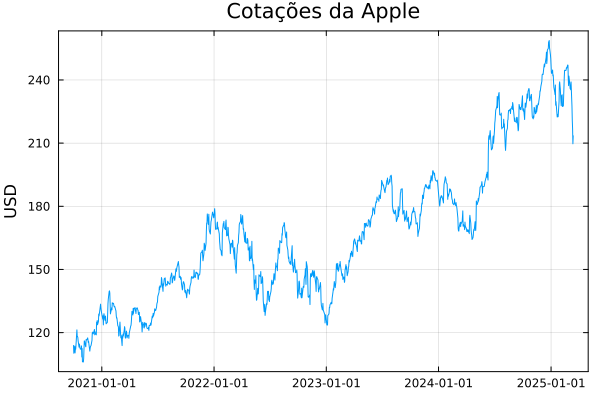

In [152]:
fig1 = plot(apple[:,:date], adjclose, title="Cotações da Apple",legend = false,ylabel="USD", framestyle = :box)

Para analisar séries cronológicas é normalmente mais indicado a utilização de retornos logarítmicos: $\log(P_t/P_{t-1})$. Julia denota por $\log(\cdot)$ a função que calcula o logarítmo de base e. Para agregação sectional, por exemplo se pretendermos calcular o retorno de uma carteira, devemos antes utilizar os retornos simples dos ativos constituintes da carteira: $(P_t-P_{t-1})/P_{t-1}$

In [154]:
# Agora que inspecionámos a evolução de cotações da Apple, vamos calcular os retornos (logaritmicos),

logr = LogReturn("AAPL", Date(2020,10,01),Date(2025,01,01)) |> DataFrame
show(logr)

1068×5 DataFrame
  Row │ ticker  date        interval  type    r
      │ String  Date        String    String  Float64
──────┼─────────────────────────────────────────────────
    1 │ AAPL    2020-10-02  1d        log     -0.032813
    2 │ AAPL    2020-10-05  1d        log      0.030327
    3 │ AAPL    2020-10-06  1d        log     -0.029089
    4 │ AAPL    2020-10-07  1d        log      0.016825
    5 │ AAPL    2020-10-08  1d        log     -0.000956
    6 │ AAPL    2020-10-09  1d        log      0.017246
    7 │ AAPL    2020-10-12  1d        log      0.061585
    8 │ AAPL    2020-10-13  1d        log     -0.026886
    9 │ AAPL    2020-10-14  1d        log      0.000743
   10 │ AAPL    2020-10-15  1d        log     -0.003968
   11 │ AAPL    2020-10-16  1d        log     -0.0141
  ⋮   │   ⋮         ⋮          ⋮        ⋮         ⋮
 1059 │ AAPL    2024-12-17  1d        log      0.009673
 1060 │ AAPL    2024-12-18  1d        log     -0.021655
 1061 │ AAPL    2024-12-19  1d        log     

In [172]:
# Selecionamos todas as linhas do dataframe (logr) e apenas a coluna :r

returns = logr[:, :r];

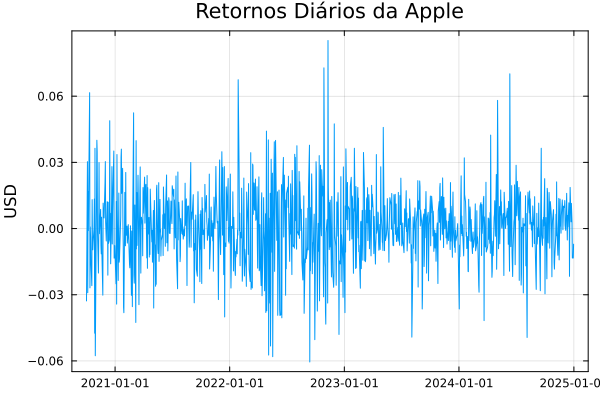

In [173]:
fig2 = plot(logr[:,:date], returns, title="Retornos Diários da Apple",legend = false, ylabel="USD", framestyle = :box)

In [176]:
# Vamos calcular de seguida (i) a média e o (ii) desvio-padrão dos retornos diários,

mu = mean(returns)
sigma = std(returns)
println("μ = ", mu)
println("σ = ", sigma)

mu = 0.0007367827715355806
sigma = 0.017069932078087432


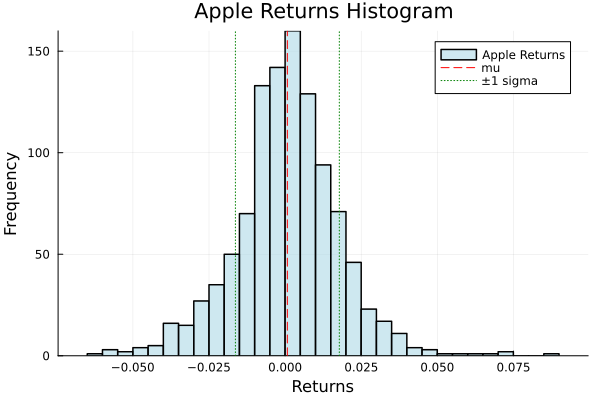

In [181]:
# Podemos visualizar o histograma dos retorns diário da Apple usando o método histogram() de Plots

fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Apple Returns",
          xlabel="Returns",
          ylabel="Frequency",
          title="Apple Returns Histogram",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e desvio-padrão

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu - sigma, mu + sigma],
       linecolor=:green, linestyle=:dot, label="±1 σ")

# O gráfico sugere que a observação de valores extremos ocorrerá com alguma frequência

display(plot!(fig3))

Em que medida uma distribuição normal representa bem a realidade empírica dos retornos da Apple observados nos últimos anos?
*   Inspeção Visual
  * $\surd$ Histograma
  * Gráficos Quantil-Quantil (infelizmente não existe no Plots)
*   Testes Estatísticos de Normalidade
  * Teste de Jarque-Bera
  * Teste de Shapiro-Wilk





In [159]:
jb_test = JarqueBeraTest(returns)
println("Jarque-Bera test p-value: ", pvalue(jb_test))

sw_test = ShapiroWilkTest(returns)
println("Shapiro-Wilk test p-value: ", pvalue(sw_test))


Jarque-Bera test p-value: 2.3794815160513136e-33
Shapiro-Wilk test p-value: 4.528248524354859e-11


Estes valores-p são realmente extremamente pequenos! Com o teste de Jarque-Bera (valor-p ≈ 2,37e-33) e o teste de Shapiro-Wilk (valor-p ≈ 4,53e-11) mostrando resultados tão significativos, temos evidência muito forte para rejeitar a hipótese nula de normalidade para os retornos da Apple.
Isto é bastante comum com dados de retornos de ações, que tipicamente apresentam:
*   Excesso de  kurtosis (caudas pesadas) - eventos extremos acontecem com mais frequência do que uma distribuição normal preveria
* Leve assimetria negativa - grandes retornos negativos tendem a ser mais extremos que grandes retornos positivos

Uma vez que rejeitámos a normalidade, ajustar uma distribuição t de Student será um bom próximo passo. Como sabemos, a distribuição t pode acomodar estas caudas pesadas através do seu parâmetro de graus de liberdade (ν). Valores mais baixos de (ν) indicam caudas mais pesadas.

In [ ]:
# Fit a normal distribution
μ, σ = mean(returns), std(returns)
normal_fit = Normal(μ, σ)

Fitted parameters: ν = 4.964901799449499, μ = 0.0008977559335466189, σ = 0.013407095972427419



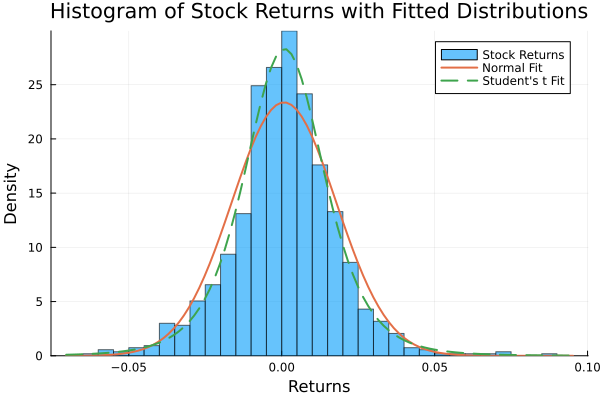

In [184]:
# Define the log-likelihood function for the Student's t distribution parametrised by ν (degrees of freedom), μ (mean), and s (scale)
function log_likelihood(params, data)
    ν, μ, s = params
    if ν <= 0 || s <= 0  # Ensure valid parameters
        return Inf  # Return a large value for invalid parameters
    end
    return -sum(logpdf(TDist(ν), (x - μ) / s) - log(s) for x in data)
end

# Initial guess for ν (degrees of freedom), μ (mean), and s (scale)
initial_guess = [5.0, mean(returns), std(returns)]  # Use sample std for (s)

# Define lower and upper bounds for the parameters
lower_bounds = [0.1, -Inf, 1e-6]  # ν > 0, μ can be any value, s > 1e-6 (very small)
upper_bounds = [Inf, Inf, Inf]    # No upper bounds for ν, μ and s


# Optimize with bounds to ensure valid parameters
result = optimize(params -> log_likelihood(params, returns), lower_bounds, upper_bounds, initial_guess, Fminbox(LBFGS()))


# Extract the fitted parameters
ν_fit, μ_fit, s_fit = result.minimizer
println("Fitted parameters: ν = ", ν_fit, ", μ = ", μ_fit, ", σ = ", s_fit, "\n")


# Create the fitted Student's t distribution
t_fit = LocationScale(μ_fit, s_fit, TDist(ν_fit))  # Use LocationScale for proper shifting/scaling

# Plot the histogram and fitted distributions
histogram(returns, bins=30, normalize=:pdf, label="Stock Returns", alpha=0.6)

# Overlay the fitted normal distribution
x_range = range(minimum(returns) - 0.01, maximum(returns) + 0.01, length=100)  # Extend x_range
plot!(x_range, pdf.(normal_fit, x_range), label="Normal Fit", linewidth=2)

# Overlay the fitted Student's t distribution
plot!(x_range, pdf.(t_fit, x_range), label="Student's t Fit", linewidth=2, linestyle=:dash)

title!("Histogram of Stock Returns with Fitted Distributions")
xlabel!("Returns")
ylabel!("Density")

